In [58]:
from itertools import combinations, product
from math import sqrt
import scipy
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F

In [2]:
def construct_hadamard_matrix(order, device='cpu'):
    lg2 = 0 if order < 1 else int(np.log2(order))
    h_matrix = torch.tensor([[1]]).to(device)
    for _ in range(lg2):
        h_matrix = torch.vstack([
            torch.hstack([h_matrix, h_matrix]),
            torch.hstack([h_matrix, -h_matrix])
        ])
    return h_matrix

In [133]:
def gaussian_regularization(input_matrix, device='cpu'):
    p = input_matrix.shape[0]
    matrix_regularization = torch.empty_like(input_matrix)
    scaling_factors = torch.empty(p, device=device)
    for col_ind in range(input_matrix.shape[1]):
        hadamard_matrix = construct_hadamard_matrix(p, device=device)
        s = (torch.eye(p) * (torch.randint(0, 2, (p, p)) * 2 - 1))
        scaling_factors[col_ind] = torch.norm(input_matrix[:, col_ind]) / np.sqrt(p)
        matrix_regularization[:, col_ind] = (s @ input_matrix[:, col_ind]) / scaling_factors[col_ind]
    return matrix_regularization, scaling_factors

In [137]:
k = 32
num_vectors = 4096
torch.manual_seed(42)

uniform_part = torch.rand(num_vectors, k) * 4 - 2
outliers = torch.randint(0, 10, (num_vectors, k)).float() * (torch.rand(num_vectors, k) < 0.05)
weights = uniform_part + outliers

In [138]:
weights_norm, scaling_factors = gaussian_regularization(weights, device='cpu')

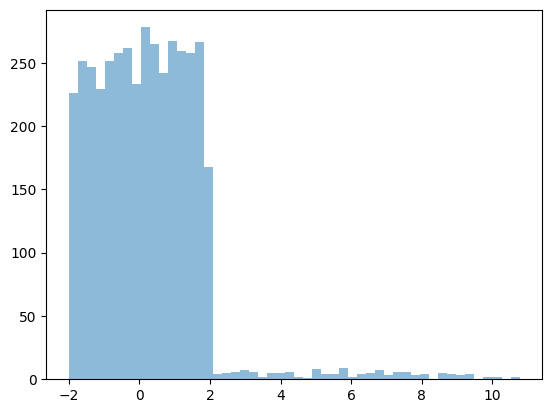

In [139]:
x = weights[:,0]
plt.hist(x, bins=50, alpha=0.5, label='Original Weights')
plt.show()

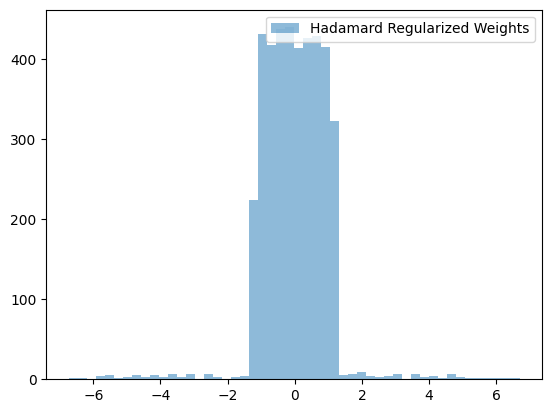

In [140]:
x_norm = weights_norm[:,0]
plt.hist(x_norm, bins=50, alpha=0.5, label='Hadamard Regularized Weights')
plt.legend()
plt.show()

In [141]:
x.mean(), x.std()

(tensor(0.2245), tensor(1.5831))

In [142]:
x_norm.mean(), x_norm.std(), 

(tensor(0.0080), tensor(1.0001))

In [177]:
def pcd(input_matrix, device='cpu'):
    num_vectors, k = input_matrix.shape
    phis = torch.zeros(num_vectors, k-1).to(device)
    magnitudes = torch.norm(input_matrix, dim=1).to(device)
    for i in range(k-1):
        input_atan2 = torch.sqrt(torch.sum(input_matrix[:, i+1:] ** 2, dim=1))
        other_atan2 = input_matrix[:, i]
        phi = torch.atan2(input_atan2, other_atan2)
        phis[:, i] = phi
    return phis, magnitudes

In [178]:
pcd(weights)

(tensor([[1.4138, 1.3980, 1.6201,  ..., 0.6479, 2.2435, 0.7548],
         [1.4099, 1.5358, 1.6392,  ..., 1.4946, 2.5463, 0.8405],
         [1.5238, 1.6028, 1.4431,  ..., 1.0848, 0.9241, 2.5070],
         ...,
         [1.8332, 1.7937, 1.6950,  ..., 2.2807, 1.6332, 0.4217],
         [1.7968, 1.6413, 1.6362,  ..., 1.3338, 1.9340, 2.3401],
         [1.3078, 1.4438, 1.7430,  ..., 0.5369, 1.8830, 2.8650]]),
 tensor([ 9.7777,  9.6367, 13.0425,  ...,  7.0969,  7.1147,  6.8760]))

In [ ]:
def e8_minimal_directions(dtype=torch.float32, device='cpu'):
    vecs = []
    # Type A
    for i, j in combinations(range(8), 2):
        for s1, s2 in product([-1.0, 1.0], repeat=2):
            v = torch.zeros(8, dtype=dtype, device=device)
            v[i] = s1
            v[j] = s2
            vecs.append(v)
    # Type B
    for signs in product([-0.5, 0.5], repeat=8):
        minus_cnt = sum(1 for s in signs if s < 0)
        if minus_cnt % 2 == 0:
            vecs.append(torch.tensor(signs, dtype=dtype, device=device))
    V = torch.stack(vecs, dim=0)
    return V

In [13]:
e8_minimal_directions()

tensor([[-1.0000, -1.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [-1.0000,  1.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        [ 1.0000, -1.0000,  0.0000,  ...,  0.0000,  0.0000,  0.0000],
        ...,
        [ 0.5000,  0.5000,  0.5000,  ..., -0.5000,  0.5000, -0.5000],
        [ 0.5000,  0.5000,  0.5000,  ...,  0.5000, -0.5000, -0.5000],
        [ 0.5000,  0.5000,  0.5000,  ...,  0.5000,  0.5000,  0.5000]])

In [56]:
def construct_direction_codebook(directions, a):
    num_centers = 2 ** a
    rand_candidate_idx = torch.randint(0, directions.size(0), (1,)).item()
    candidates_idx = [rand_candidate_idx]
    for _ in range(1, num_centers):
        codebook = directions[candidates_idx]
        sims = directions @ codebook.T
        max_sim, _ = sims.max(dim=1)
        max_sim[candidates_idx] = 1e9
        next_candidate_idx = torch.argmin(max_sim).item()
        candidates_idx.append(next_candidate_idx)
    return directions[candidates_idx]

In [57]:
e8_directions = e8_minimal_directions()
a = 4
codebook = construct_direction_codebook(e8_directions, a)
codebook

tensor([[ 0.5000, -0.5000,  0.5000, -0.5000, -0.5000, -0.5000,  0.5000,  0.5000],
        [-0.5000,  0.5000, -0.5000,  0.5000,  0.5000,  0.5000, -0.5000, -0.5000],
        [-1.0000, -1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000, -1.0000, -1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  1.0000,  1.0000,  0.0000,  0.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000, -1.0000,  1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  1.0000, -1.0000,  0.0000,  0.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000, -1.0000,  1.0000],
        [ 0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  1.0000, -1.0000],
        [-0.5000,  0.5000, -0.5000,  0.5000, -0.5000, -0.5000,  0.5000,  0.5000],
        [-0.5000,  0.5000,  0.5000, -0.5000, -0.5000, -0.5000, -0.5000, -0.5000],
        [-0.5000

In [97]:
def fisher_transform(k, tau):
    z_standard_max_r = stats.Normal(mu=0, sigma=1).icdf(tau)
    z_max_r = z_standard_max_r + np.sqrt(2 * k - 1)
    max_r2 = z_max_r ** 2 / 2
    return max_r2

In [98]:
def wh_transform(k, tau):
    z_standard_max_r = stats.Normal(mu=0, sigma=1).icdf(tau)
    z_max_r = z_standard_max_r * np.sqrt(2/(9*k)) + 1 - 2/(9*k)
    max_r2 = k * z_max_r**3
    return max_r2

In [99]:
def table_compare_quantiles(ks=(20,50,100,500,1000), taus=(0.9,0.95,0.99,0.999)):
    rows = []
    for kdim in ks:
        for t in taus:
            x_fisher = fisher_transform(kdim, t)
            x_wh = wh_transform(kdim, t)
            x_true = stats.chi2.ppf(t, df=kdim)
            rel_f = (x_fisher - x_true)/x_true
            rel_wh = (x_wh - x_true)/x_true
            rows.append((kdim, t, x_true, x_fisher, rel_f, x_wh, rel_wh))
            # print("k tau true(chi2) fisher rel.err WH rel.err")
    for r in rows:
        print(f"{r[0]:>2} {r[1]:>5.3f} {r[2]:>11.6f} {r[3]:>11.6f} {r[4]:>+8.3%} {r[5]:>11.6f} {r[6]:>+8.3%}")

In [100]:
table_compare_quantiles()

20 0.900   28.411981   28.324474  -0.308%   28.398895  -0.046%
20 0.950   31.410433   31.124879  -0.909%   31.401686  -0.028%
20 0.990   37.566235   36.733985  -2.215%   37.591439  +0.067%
20 0.999   45.314747   43.573262  -3.843%   45.440030  +0.276%
50 0.900   63.167121   63.072464  -0.150%   63.159377  -0.012%
50 0.950   67.504807   67.218859  -0.424%   67.500552  -0.006%
50 0.990   76.153891   75.352816  -1.052%   76.171856  +0.024%
50 0.999   86.660815   85.022191  -1.891%   86.739790  +0.091%
100 0.900  118.498004  118.399697  -0.083%  118.492761  -0.004%
100 0.950  124.342113  124.056288  -0.230%  124.339593  -0.002%
100 0.990  135.806723  135.023122  -0.577%  135.820083  +0.010%
100 0.999  149.449253  147.867859  -1.058%  149.504630  +0.037%
500 0.900  540.930308  540.827138  -0.019%  540.928123  -0.000%
500 0.950  553.126809  552.841597  -0.052%  553.125986  -0.000%
500 0.990  576.492813  575.734734  -0.131%  576.499140  +0.001%
500 0.999  603.446006  601.947621  -0.248%  603.

In [101]:
def find_max_r_bisection(k, tau):
    upper_bound = 2 * np.sqrt(k)
    lower_bound = 0.0
    for _ in range(20):
        mid = (upper_bound + lower_bound) / 2
        p = stats.chi2.cdf(mid**2, df=k)
        if p < tau:
            lower_bound = mid
        else:
            upper_bound = mid
    return upper_bound

In [ ]:
ks=(20,50,100,500,1000)
taus=(0.9,0.95,0.99,0.999)
rows = []
for kdim in ks:
    for t in taus:
        x_bisection = find_max_r_bisection(kdim, t)**2
        x_true = stats.chi2.ppf(t, df=kdim)
        rel_b = (x_bisection - x_true)/x_true
        rows.append((kdim, t, x_true, x_bisection, rel_b))
for r in rows:
    print(f"{r[0]:>2} {r[1]:>5.3f} {r[2]:>11.6f} {r[3]:>11.6f} {r[4]:>+8.3%}")

20 0.900   28.411981   28.412070  +0.000%
20 0.950   31.410433   31.410518  +0.000%
20 0.990   37.566235   37.566272  +0.000%
20 0.999   45.314747   45.314803  +0.000%
50 0.900   63.167121   63.167147  +0.000%
50 0.950   67.504807   67.504963  +0.000%
50 0.990   76.153891   76.153949  +0.000%
50 0.999   86.660815   86.660834  +0.000%
100 0.900  118.498004  118.498386  +0.000%
100 0.950  124.342113  124.342441  +0.000%
100 0.990  135.806723  135.807165  +0.000%
100 0.999  149.449253  149.449655  +0.000%
500 0.900  540.930308  540.931881  +0.000%
500 0.950  553.126809  553.127340  +0.000%
500 0.990  576.492813  576.493616  +0.000%
500 0.999  603.446006  603.446738  +0.000%
1000 0.900 1057.723901 1057.725121  +0.000%
1000 0.950 1074.679449 1074.682154  +0.000%
1000 0.990 1106.968994 1106.972988  +0.000%
1000 0.999 1143.917093 1143.919942  +0.000%


In [117]:
def construct_magnitude_codebook(bits_for_magnitude, k, tau, tol, max_iters):
    num_centers = 2 ** bits_for_magnitude
    max_r = find_max_r_bisection(k, tau)
    codebook = torch.linspace(0, max_r, num_centers + 1)
    codebook = 0.5 * (codebook[:-1] + codebook[1:])
    for _ in range(max_iters):
        u = torch.empty(num_centers + 1)
        u[0] = 0.0
        u[-1] = max_r
        u[1: -1] = 0.5*(codebook[:-1] + codebook[1:])
        max_loss = 0.0
        codebook_tmp = torch.empty_like(codebook)
        for i in range(num_centers):
            num = scipy.special.gammainc((k + 1) / 2.0, np.float32((u[i + 1]**2) / 2.0)) - scipy.special.gammainc((k + 1) / 2.0, np.float32((u[i]**2) / 2.0))
            den = scipy.special.gammainc(k / 2.0, np.float32((u[i + 1]**2) / 2.0)) - scipy.special.gammainc(k / 2.0, np.float32((u[i]**2) / 2.0))
            cur = np.sqrt(2.0) * scipy.special.gamma((k + 1) / 2.0) / scipy.special.gamma(k / 2.0) * (num / (den + 1e-12))
            max_loss = max(max_loss, np.abs(cur - np.float32(codebook[i])))
            codebook_tmp[i] = cur
        codebook = codebook_tmp
        if max_loss < tol:
            break
    return codebook

In [118]:
torch.manual_seed(42)
np.random.seed(42)
k = 8
num_vectors = 1000
uniform_part = torch.rand(num_vectors, k) * 4 - 2
outliers = torch.randint(0, 10, (num_vectors, k)).float() * (torch.rand(num_vectors, k) < 0.05)
weights = uniform_part + outliers

a_bits = 5
b_bits = 3
e8_directions = e8_minimal_directions()
C_phi = construct_direction_codebook(e8_directions, a_bits)
C_r = construct_magnitude_codebook(b_bits, k, 0.99, 1e-3, 100)
print(f"Direction codebook: {C_phi.shape}", C_phi[:3])
print(f"Magnitude codebook: {C_r.shape}", C_r)

Direction codebook: torch.Size([32, 8]) tensor([[-0.5000,  0.5000,  0.5000, -0.5000,  0.5000, -0.5000,  0.5000, -0.5000],
        [ 0.5000, -0.5000, -0.5000,  0.5000, -0.5000,  0.5000, -0.5000,  0.5000],
        [-1.0000, -1.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000,  0.0000]])
Magnitude codebook: torch.Size([8]) tensor([1.4241, 1.8740, 2.2255, 2.5455, 2.8623, 3.1978, 3.5805, 4.0698])
